In [ ]:
import os
import cv2
import yaml
import math
import shutil
import random
import zipfile

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image, display, clear_output
from PIL import Image

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
#import os

directorio = '/content/drive/My Drive/dataset'
# directorio = '/content/drive/My Drive/ct_images_2'
# directorio = '/content/drive/My Drive/d3'

# Verificar si el directorio existe
if not os.path.exists(directorio):
    print(f"El directorio '{directorio}' no existe.")
else:
    print(f"El directorio '{directorio}' existe.")

# Listar archivos en el directorio
for archivo in os.listdir(directorio):
    print(archivo)


El directorio '/content/drive/My Drive/dataset' existe.
README.roboflow.txt
data.yaml
README.dataset.txt
test
valid
train


In [ ]:
import shutil

# Copiar el directorio completo a Colab
destino = '/content/dataset'
shutil.copytree(directorio, destino)


'/content/dataset'

# Importación de YOLO

In [ ]:
!git clone https://github.com/ultralytics/yolov5  # Clonar el repositorio de YOLOv5
%cd yolov5
%pip install -r requirements.txt  # Instalar las dependencias
%pip install comet_ml

Cloning into 'yolov5'...
remote: Enumerating objects: 16982, done.
remote: Counting objects: 100% (177/177), done.
remote: Compressing objects: 100% (124/124), done.
remote: Total 16982 (delta 91), reused 109 (delta 53), pack-reused 16805 (from 1)
Receiving objects: 100% (16982/16982), 15.71 MiB | 7.82 MiB/s, done.
Resolving deltas: 100% (11620/11620), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.7/882.7 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 9.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 694.9/694.9 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 979.1/979.1 kB 46.8 MB/s eta 0:00:00
   ━

In [ ]:
# Entrenar el modelo
!python /content/yolov5/train.py --img 416 --batch 16 --epochs 100 --data /content/dataconfig.yaml --weights yolov5s.pt --cache


**Evaluar y Usar el Modelo**

In [ ]:
!python val.py --weights runs/train/exp/weights/best.pt --single-cls --img 416 --conf 0.1 --data /content/dataconfig.yaml

In [ ]:
!python detect.py --weights runs/train/exp/weights/best.pt --img 416 --conf 0.1 --source /content/ct_images/images/val


# **Dataset**

In [ ]:
!pwd

/content


In [ ]:
def read_label_txt(file_path):
    with open(file_path, 'r') as file:
        # lines = file.readlines()
        # # La primera línea contiene la clase
        # label = lines[0].strip()
        data = file.read()
        try: label = data.split()[0]
        except IndexError:
          print(data)
          label = '10'

    return label


def move_random_files(source_folder, destination_folder, num_files):
  """Moves a random subset of files from source_folder to destination_folder.

  Args:
    source_folder: The path to the source folder.
    destination_folder: The path to the destination folder.
    num_files: The number of files to move.
  """

  # Get a list of all files in the source folder
  files = os.listdir(source_folder)

  # Check if there are enough files to move
  if num_files > len(files):
    raise ValueError("num_files cannot be greater than the number of files in the source folder.")

  # Select a random subset of files
  random_files = random.sample(files, num_files)

  # Move the selected files to the destination folder
  for file in random_files:
    source_path = os.path.join(source_folder, file)
    destination_path = os.path.join(destination_folder, file)
    shutil.move(source_path, destination_path)

    label_path = source_path.replace('.jpg', '.txt').replace('/images/', '/labels/')
    label_destination_path = destination_path.replace('.jpg', '.txt').replace('/images/', '/labels/')
    shutil.move(label_path, label_destination_path)


In [ ]:
test_labels = os.listdir('/content/dataset/test/labels') # '/content/test/labels

image_path = f'/content/dataset/test/images/{test_labels[0].replace(".txt", ".jpg")}'

# Get the file size in bytes
file_size = os.path.getsize(image_path)

print(f"File size: {file_size} bytes")

image = Image.open(image_path)

width, height = image.size

print(f"Image width: {width}")
print(f"Image height: {height}")

File size: 27929 bytes
Image width: 512
Image height: 512


In [ ]:
# Modify a yml file
def modify_yaml(file_path):
  file_path = '/content/dataset/data.yaml'
  with open(file_path, 'rw') as file:
      data = yaml.safe_load(file)
      print(data)
      data['train'] = '/content/dataset/train/images'
      data['val'] = '/content/dataset/val/images'
      data['test'] = '/content/dataset/test/images'

      yaml.dump(data, file)


# Create a yml file
def create_yaml(file_path):
  data = {
      'path': '/content/ct_images/',
      'train': 'images/train',
      'val': 'images/val',
      'test': None,  # Optional key, set to None for now
      'nc': 2,  # Número de clases
      'names': ['Nodules', 'NonNodules']  # Nombres de las clases
  }

  # Specify the file path for the new YAML file
  file_path = '/content/dataconfig.yaml'

  # Write the YAML content to the file
  with open(file_path, 'w') as file:
      yaml.dump(data, file)

In [ ]:
!cat /content/dataset/data.yaml

path: /content/dataset/
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['0']

roboflow:
  workspace: school-wo8fx
  project: lung-final
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/school-wo8fx/lung-final/dataset/1

#### Generación Test data

In [ ]:
# Copiar el directorio completo a Colab
destino = '/content/test'
directorio = '/content/dataset/test'
shutil.copytree(directorio, destino)

'/content/test'

In [ ]:
# Example usage
source_folder = "/content/valid/images"
destination_folder = "/content/test/images/"
num_files = 25

move_random_files(source_folder, destination_folder, num_files)

In [ ]:
total_images = os.listdir('/content/test/images')
total_labels = os.listdir('/content/test/labels')
print(len(total_images))
print(len(total_labels))

200
200


# **Entrenamiento**

## YOLO (Roboflow dataset) d1

#### **Opción usando API**

In [ ]:
!pip install inference-sdk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.5/151.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 5.1 MB/s eta 0:00:00


In [ ]:
from inference_sdk import InferenceHTTPClient

In [ ]:
CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
    api_key="ALBCieoNNRtsYBZifylR"
)

result = CLIENT.infer('/content/LIDC-IDRI-0016-51_img_jpg.rf.99b4a7803e80c5e9d85f8a0fd8afef4e.jpg', model_id="lung-nodule-detection-extra/4")

## YOLO D3

**Entrenamiento del modelo**

In [ ]:
!python /content/yolov5/train.py --img 640 --batch 16 --epochs 100 --data /content/data.yaml --weights yolov5s.pt --cache
# --img 416

Se han truncado las últimas 5000 líneas del flujo de salida.
      80/99      4.38G    0.02532   0.003567   0.001076         17        640:  39%|███▉      | 47/121 [00:15<00:29,  2.48it/s]/content/yolov5/train.py:412: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      80/99      4.38G    0.02519   0.003559   0.001064         20        640:  40%|███▉      | 48/121 [00:15<00:28,  2.55it/s]/content/yolov5/train.py:412: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      80/99      4.38G    0.02525   0.003565   0.001143         24        640:  40%|████      | 49/121 [00:16<00:29,  2.46it/s]/content/yolov5/train.py:412: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.aut

**Validación para obtener métricas**

In [ ]:
!python val.py --weights runs/train/exp/weights/best.pt --single-cls --img 640 --conf 0.1 --data /content/data.yaml

val: data=/content/data.yaml, weights=['runs/train/exp/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.1, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=True, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
WARNING ⚠️ confidence threshold 0.1 > 0.001 produces invalid results
YOLOv5 🚀 v7.0-371-g6629839d Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
val: Scanning /content/valid/labels.cache... 473 images, 0 backgrounds, 0 corrupt: 100% 473/473 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 15/15 [00:07<00:00,  2.03it/s]
                   all        473        473      0.561      0.476      0.519        0.3
Speed: 0.6ms pre-process, 7.2ms inference, 2.2ms NMS per image at s

In [ ]:
!python val.py --weights runs/train/exp/weights/best.pt --data /content/data.yaml --img 640 --conf 0.1 --task test


val: data=/content/data.yaml, weights=['runs/train/exp/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.1, iou_thres=0.6, max_det=300, task=test, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
WARNING ⚠️ confidence threshold 0.1 > 0.001 produces invalid results
YOLOv5 🚀 v7.0-371-g6629839d Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
test: Scanning /content/test/labels... 103 images, 0 backgrounds, 0 corrupt: 100% 103/103 [00:00<00:00, 1621.26it/s]
test: New cache created: /content/test/labels.cache
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 4/4 [00:05<00:00,  1.26s/it]
                   all        103        103      0.432      0.416      0.477      0.302
           

**Detección de los objetos en el conjunto de Test**

In [ ]:
!python detect.py --weights runs/train/exp/weights/best.pt --img 640 --conf 0.1 --source /content/test/images

detect: weights=['runs/train/exp/weights/best.pt'], source=/content/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.1, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-371-g6629839d Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/103 /content/test/images/0164_NI008_slice001_png.rf.76e90aff14472a9e1cc6cf9f46b827cf.jpg: 640x640 1 1, 11.4ms
image 2/103 /content/test/images/0166_NI000_slice001_png.rf.fddebf71be95efd9adb6111fbafd6bf0.jpg: 640x640 1 1, 11.5ms
image 3/103 /content/test/images/0166_NI000_slice002_png.rf.17f96d84bd9ba602ec

**Detección de YOLO añadiendo txt indicando la posición**

In [ ]:
!python detect.py --weights runs/train/exp/weights/best.pt --img 510 --source /content/test/images --save-txt --save-conf

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
detect: weights=['runs/train/exp/weights/best.pt'], source=/content/test/images, data=data/coco128.yaml, imgsz=[510, 510], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-372-ga3555241 Python-3.10.12 torch-2.4.1+cu121 CPU

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
WARNING ⚠️ --img-size [510, 

In [ ]:
# Copiar el directorio completo a Colab
directorio = '/content/yolov5/runs/detect/exp'
destino = '/content/detection/'
shutil.copytree(directorio, destino)

'/content/detection/'

# **Comprimir los parámetros y resultados de YOLO**

In [ ]:
def zip_folder(folder_path, output_zip):
    with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
        # Recorremos todos los archivos y carpetas en el directorio
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                # Agrega cada archivo al archivo zip, manteniendo la estructura de carpetas
                file_path = os.path.join(root, file)
                zipf.write(file_path, os.path.relpath(file_path, folder_path))


In [ ]:
# folder_path = '/content/yolov5/runs/detect/exp'
folder_path = '/content/bbimages'
output_zip = '/content/bbimagesTest.zip'
zip_folder(folder_path, output_zip)

# Evaluación YOLO

In [ ]:
TN = 0
FP = 0
FN = 0
TP = 0

for label in os.listdir('/content/test/labels'):
  if label not in os.listdir('/content/detection/labels'): # El modelo ha predicho Non Nodule
    if '1' in read_label_txt(f'/content/test/labels/{label}'): # Está etiquetado como Non Nodule -> Acierto
      TN += 1
    else:     # Está etiquetado como Nodule por lo tanto error
      FN += 1
  else:       # El modelo ha predicho Nodule
    if '0' in read_label_txt(f'/content/test/labels/{label}'): # Está etiquetado como Nodule -> Acierto
      TP += 1
    else:     # Está etiquetado como Non Nodule por lo tanto error
      FP += 1


In [ ]:
negative_total = 0
positive_total = 0
for label in os.listdir('/content/test/labels'):
  value = read_label_txt(f'/content/test/labels/{label}')
  if value == '1':
    negative_total += 1
  else:
    positive_total += 1

print(negative_total)
print(positive_total)

50
150



 [[108  39]
 [ 11  42]] 



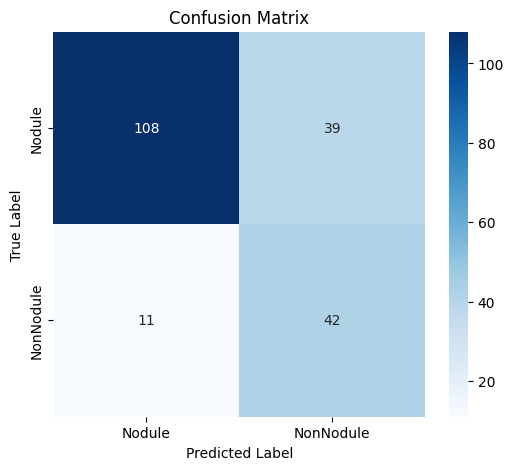

In [ ]:
cm = np.array([[TP, FN], [FP, TN]])
print('\n', cm, '\n')
# Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 5))
# Replace val_generator.class_indices.keys() with your actual class labels
class_labels = ['Nodule', 'NonNodule'] # Update this with your actual class names
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

# **Cálculo IoU**

### Funciones

In [ ]:
# Lectura del archivo delvolviendo un diccionario con cada uno de los campos
def read_txt_file(file_path):
    with open(file_path, 'r') as file:
        # lines = file.readlines()
        data = file.read()
        labels = data.split()
        result = {}
        result['class'] = labels[0]
        result['coordenates'] = [float(labels[1]), float(labels[2]), float(labels[3]), float(labels[4])]
        if len(labels) > 5:
          result['confidence'] = float(labels[5])
    return result

# Lectura del archivo y devolviendo una lista de listas con las coordenadas de los nódulos
def read_txt(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
        result = []
        for line in lines:
          labels = line.split()
          coordenates = [float(labels[1]), float(labels[2]), float(labels[3]), float(labels[4])]
          result.append(coordenates)
    return result

In [ ]:
lines = read_txt('/content/detection/labels/LIDC-IDRI-0016-51_img_jpg.rf.99b4a7803e80c5e9d85f8a0fd8afef4e.txt')
print(lines)

[[0.674805, 0.341797, 0.00976562, 0.0078125], [0.838867, 0.666992, 0.00976562, 0.00976562]]


In [ ]:
def txt_yolo_check(file_path):

  with open(file_path, 'r') as file:
    data = file.read()
    labels = data.split()
    if len(labels) > 2:
      return True
    else:
      return False


def desnormalize_coordenates(box, size): # box = [x_center, y_center, width, height] / size = [x pixels image, y pixels image]

  x_center = box[0]
  y_center = box[1]
  width = box[2]
  height = box[3]

  x_center_real = x_center * size[0] # x sixe
  y_center_real = y_center * size[1] # y size
  width_real = width * size[0]
  height_real = height * size[1]


  x_min = x_center_real - width_real / 2
  y_min = y_center_real - height_real / 2
  x_max = x_center_real + width_real / 2
  y_max = y_center_real + height_real / 2

  return [x_min, y_min, x_max, y_max]


def calculate_iou(box1, box2):
    # box1 y box2 son listas o tuplas en formato [x_min, y_min, x_max, y_max]

    x_min_inter = max(box1[0], box2[0])
    y_min_inter = max(box1[1], box2[1])
    x_max_inter = min(box1[2], box2[2])
    y_max_inter = min(box1[3], box2[3])

    # Calcular las dimensiones del área de superposición
    inter_width = max(0, x_max_inter - x_min_inter)
    inter_height = max(0, y_max_inter - y_min_inter)

    # Área de superposición
    inter_area = inter_width * inter_height

    # Área de las dos cajas individuales
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # Área de unión
    union_area = box1_area + box2_area - inter_area

    # IoU
    iou = inter_area / union_area if union_area != 0 else 0

    return iou


###  **Subconjunto de test con coordenadas de Yolo para el cálculo**

In [ ]:
detections_labels = os.listdir('/content/detection/labels/')
test_labels = os.listdir('/content/test/labels/')

size_image = [510, 510]

In [ ]:
total_detections = []
total_test = []

for label in test_labels:
  if txt_yolo_check(f'/content/test/labels/{label}'):
    total_test.append(label)

for label in total_test:
  if label in detections_labels:
    total_detections.append(label)

print(len(total_test))
print(len(total_detections))

120
98


### Cálculo

Teniendo en cuenta de que puede haber más de un nódulo por imagen

In [ ]:
iou_list = []

for result in total_detections:

  boxes1 = read_txt(f'/content/detection/labels/{result}')
  boxes2 = read_txt(f'/content/test/labels/{result}')

  if len(boxes1) == len(boxes2):
    for i in range(len(boxes1)):
      b1 = boxes1[i]
      b2 = boxes2[i]

      iou = calculate_iou(box1=desnormalize_coordenates(box=b1, size=size_image), box2=desnormalize_coordenates(box=b2, size=size_image))
      iou = iou.math.ceil(iou) # Redondeamos al alto
      iou_list.append(iou)

  else:
    min_detections = min(len(boxes1), len(boxes2))
    for i in range(min_detections):
      b1 = boxes1[i]
      b2 = boxes2[i]

      iou = calculate_iou(box1=desnormalize_coordenates(box=b1, size=size_image), box2=desnormalize_coordenates(box=b2, size=size_image))
      iou = math.ceil(iou) # Redondeamos al alto
      iou_list.append(iou)

    differece = abs(len(boxes1) - len(boxes2))
    for i in range(differece):
      iou_list.append(0)


Realizado solo con el 1º nódulo presente en la imagen

In [ ]:
error_clasification = []
iou_list = []

for result in detections_labels:

  b1 = read_txt_file(f'/content/detection/{result}')
  b2 = read_txt_file(f'/content/test/{result}')

  if b1['class'] == b2['class']:
    iou = calculate_iou(box1=desnormalize_coordenates(box=b1['coordenates'], size=size_image), box2=desnormalize_coordenates(box=b2['coordenates'], size=size_image))
    iou_list.append(iou)
  else:
    error_clasification.append(result)



**Resultado**

In [ ]:
media = sum(iou_list) / len(iou_list)
print(media)
# print(len(error_clasification))
# print(error_clasification)

0.3536532987068628


# BoundBoxes en las imágenes originales

In [ ]:
# Función para dibujar los bounding boxes de YOLO en la imagen
def draw_yolo_bboxes(img_path, label_path, class_names):
    # Cargar la imagen
    img = cv2.imread(img_path)
    height, width, _ = img.shape

    # Leer el archivo de etiquetas (formato YOLO)
    with open(label_path, 'r') as f:
        labels = f.readlines()

    # Dibujar cada bounding box en la imagen
    for label in labels:
        # Descomponer cada línea del archivo de etiquetas
        class_id, x_center, y_center, w, h = map(float, label.split())

        # Convertir las coordenadas normalizadas a coordenadas absolutas
        x1 = int((x_center - w / 2) * width)
        y1 = int((y_center - h / 2) * height)
        x2 = int((x_center + w / 2) * width)
        y2 = int((y_center + h / 2) * height)

        # Dibujar el bounding box
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Colocar el nombre de la clase en la imagen
        label = f'{class_names[int(class_id)]}'
        cv2.putText(img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Mostrar la imagen con los bounding boxes
    cv2.imwrite(f'/content/bbimages/{os.path.basename(img_path)}', img)
    # cv2.imshow("Imagen con Bounding Boxes", img)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()



In [ ]:
# Definir el directorio de las imágenes y las etiquetas
image_dir = '/content/dataset/test/images'
label_dir = '/content/dataset/test/labels'

# Nombres de las clases (puedes reemplazar esto con tus propias clases)
class_names = ['clase0', 'clase1', 'clase2', 'clase3']

# Iterar sobre las imágenes y sus etiquetas correspondientes
for img_file in os.listdir(image_dir):
    if img_file.endswith(".jpg") or img_file.endswith(".png"):
        img_path = os.path.join(image_dir, img_file)
        label_path = os.path.join(label_dir, img_file.replace('.jpg', '.txt').replace('.png', '.txt'))

        # Verificar si el archivo de etiquetas existe antes de proceder
        if os.path.exists(label_path):
            draw_yolo_bboxes(img_path, label_path, class_names)
        else:
            print(f"No se encontró el archivo de etiquetas para la imagen: {img_file}")

In [ ]:
print(len(os.listdir('/content/bbimages')))

95
